In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

# -----------------------------
# PARAMETERS
# -----------------------------
n_customers = 5000
n_products = 200
n_orders = 50000

# -----------------------------
# CUSTOMERS TABLE
# -----------------------------
customers = pd.DataFrame({
    'customer_id': np.arange(1, n_customers + 1),
    'state': np.random.choice(['Lagos', 'Abuja', 'Rivers', 'Oyo', 'Kano'], n_customers),
    'signup_date': pd.to_datetime(
        np.random.choice(pd.date_range('2019-01-01', '2023-12-31'), n_customers)
    )
})

# -----------------------------
# PRODUCTS TABLE
# -----------------------------
products = pd.DataFrame({
    'product_id': np.arange(1, n_products + 1),
    'category': np.random.choice(['Electronics', 'Fashion', 'Home Appliances'], n_products),
    'base_price': np.random.uniform(5000, 500000, n_products)
})

# -----------------------------
# ORDERS TABLE (MULTI-YEAR)
# -----------------------------
orders = pd.DataFrame({
    'order_id': np.arange(1, n_orders + 1),
    'customer_id': np.random.choice(customers['customer_id'], n_orders),
    'product_id': np.random.choice(products['product_id'], n_orders),
    'order_date': pd.to_datetime(
        np.random.choice(pd.date_range('2020-01-01', '2024-12-31'), n_orders)
    ),
    'quantity': np.random.randint(1, 5, n_orders),
    'discount': np.random.uniform(0, 0.3, n_orders),
    'marketing_touch': np.random.binomial(1, 0.4, n_orders),
    'delivery_time_days': np.random.randint(1, 14, n_orders)
})

# -----------------------------
# MERGE TABLES
# -----------------------------
df = orders.merge(customers, on='customer_id')
df = df.merge(products, on='product_id')

# -----------------------------
# BUSINESS LOGIC (REALISTIC)
# -----------------------------
df['unit_price'] = df['base_price'] * (1 - df['discount'])
df['revenue'] = df['unit_price'] * df['quantity']

# cost is not perfectly linear (important)
df['cost_price'] = df['unit_price'] * np.random.uniform(0.6, 0.9, len(df))

df['profit'] = df['revenue'] - df['cost_price']

# -----------------------------
# CUSTOMER BEHAVIOR FEATURES
# -----------------------------
customer_agg = df.groupby('customer_id').agg({
    'order_id': 'count',
    'revenue': 'sum',
    'profit': 'sum',
    'delivery_time_days': 'mean'
}).rename(columns={
    'order_id': 'purchase_frequency',
    'revenue': 'customer_lifetime_value',
    'profit': 'total_profit'
}).reset_index()

# Merge aggregated features
df = df.merge(customer_agg, on='customer_id')

# -----------------------------
# FIX DUPLICATE COLUMNS (CRITICAL)
# -----------------------------
df.rename(columns={
    'delivery_time_days_y': 'avg_delivery_time'
}, inplace=True)

df.drop(columns=['delivery_time_days_x'], inplace=True)

# -----------------------------
# TARGET VARIABLE (REALISTIC LOGIC)
# -----------------------------
prob = (
    0.3 * (df['purchase_frequency'] / df['purchase_frequency'].max()) +
    0.3 * (df['customer_lifetime_value'] / df['customer_lifetime_value'].max()) +
    0.2 * (1 - df['avg_delivery_time'] / df['avg_delivery_time'].max()) +
    0.2 * df['marketing_touch']
)

# Add noise (VERY IMPORTANT)
prob = prob + np.random.normal(0, 0.15, len(df))

# Convert to binary
df['is_repeat_customer'] = (prob > 0.5).astype(int)

# -----------------------------
# FINAL CLEAN DATASET
# -----------------------------
df = df.drop(columns=['base_price'])

# Preview
df.head()

,order_id,customer_id,product_id,order_date,quantity,discount,marketing_touch,state,signup_date,category,unit_price,revenue,cost_price,profit,purchase_frequency,customer_lifetime_value,total_profit,avg_delivery_time,is_repeat_customer
0,1,447,188,2020-09-06,2,0.076731,1,Rivers,2021-07-09,Fashion,308122.368456,616244.736912,245832.401247,370412.335665,11,4.430642e+06,2.566033e+06,7.000000,0
1,2,109,178,2020-11-05,3,0.208005,1,Rivers,2019-12-07,Home Appliances,332625.762716,997877.288149,216831.301076,781045.987073,8,4.494520e+06,2.999132e+06,6.000000,0
2,3,4413,129,2024-07-23,2,0.045394,0,Abuja,2021-04-06,Electronics,380570.283407,761140.566814,253766.696737,507373.870077,11,6.276278e+06,4.021396e+06,7.272727,0
3,4,3240,97,2024-07-18,3,0.091965,1,Oyo,2023-04-10,Home Appliances,20912.592755,62737.778265,13508.689403,49229.088863,12,5.812843e+06,4.240822e+06,7.000000,1
4,5,4054,109,2020-04-15,3,0.187145,0,Kano,2021-11-11,Home Appliances,252276.067997,756828.203991,218641.868842,538186.335148,18,1.100256e+07,7.787754e+06,6.555556,1


In [2]:
# Preview dataset info
df.info

<bound method DataFrame.info of        order_id  customer_id  product_id order_date  quantity  discount  \
0             1          447         188 2020-09-06         2  0.076731   
1             2          109         178 2020-11-05         3  0.208005   
2             3         4413         129 2024-07-23         2  0.045394   
3             4         3240          97 2024-07-18         3  0.091965   
4             5         4054         109 2020-04-15         3  0.187145   
...         ...          ...         ...        ...       ...       ...   
49995     49996         3147          80 2021-04-19         4  0.234329   
49996     49997         1783         128 2022-07-12         1  0.135631   
49997     49998         2549         152 2020-05-09         3  0.124775   
49998     49999         1751          41 2021-11-29         4  0.176902   
49999     50000         2014         200 2024-05-08         1  0.274302   

       marketing_touch   state signup_date         category     uni

In [3]:
# Preview dataset descriptions
df.describe()

,order_id,customer_id,product_id,order_date,quantity,discount,marketing_touch,signup_date,unit_price,revenue,cost_price,profit,purchase_frequency,customer_lifetime_value,total_profit,avg_delivery_time,is_repeat_customer
count,50000.000000,50000.000000,50000.000000,50000,50000.000000,5.000000e+04,50000.000000,50000,50000.000000,5.000000e+04,50000.000000,5.000000e+04,50000.000000,5.000000e+04,5.000000e+04,50000.000000,50000.000000
mean,25000.500000,2499.734880,100.452980,2022-07-05 18:15:31.391999744,2.499600,1.506725e-01,0.399920,2021-07-04 14:00:23.039999744,212158.494282,5.304836e+05,159157.315647,3.713262e+05,10.981640,5.829500e+06,4.079932e+06,6.991440,0.347660
min,1.000000,1.000000,1.000000,2020-01-01 00:00:00,1.000000,6.828812e-07,0.000000,2019-01-01 00:00:00,4532.212422,4.540229e+03,2769.533151,5.526867e+02,1.000000,1.219339e+05,1.950808e+04,1.500000,0.000000
25%,12500.750000,1258.000000,51.000000,2021-04-06 00:00:00,1.000000,7.557973e-02,0.000000,2020-04-07 00:00:00,116216.754906,2.016304e+05,85160.097857,6.793011e+04,9.000000,4.257523e+06,2.885461e+06,6.166667,0.000000
50%,25000.500000,2500.000000,101.000000,2022-07-06 00:00:00,2.000000,1.510095e-01,0.000000,2021-07-07 00:00:00,201806.698987,4.158895e+05,151018.483300,2.753737e+05,11.000000,5.655308e+06,3.920935e+06,7.000000,0.000000
75%,37500.250000,3742.000000,151.000000,2023-10-06 00:00:00,4.000000,2.257586e-01,1.000000,2022-09-25 00:00:00,318753.675468,7.732302e+05,235134.613231,5.639625e+05,13.000000,7.172270e+06,5.092370e+06,7.800000,1.000000
max,50000.000000,5000.000000,200.000000,2024-12-31 00:00:00,4.000000,2.999953e-01,1.000000,2023-12-31 00:00:00,498138.401404,1.992554e+06,447804.448908,1.668314e+06,23.000000,1.605648e+07,1.226807e+07,13.000000,1.000000
std,14433.901067,1442.098626,57.679067,NaN,1.122098,8.660781e-02,0.489887,NaN,125546.179109,4.179012e+05,96509.980266,3.533979e+05,3.158073,2.188887e+06,1.670428e+06,1.189431,0.476232


In [4]:
# -----------------------------
# TIME-BASED SPLIT + FEATURES
# -----------------------------
df = df.sort_values('order_date')

split_date = df['order_date'].quantile(0.8)

train = df[df['order_date'] <= split_date]
test = df[df['order_date'] > split_date]

features = [
    'quantity',
    'discount',
    'marketing_touch',
    'purchase_frequency',
    'avg_delivery_time'
]

X_train = train[features]
y_train = train['is_repeat_customer']

X_test = test[features]
y_test = test['is_repeat_customer']

In [5]:
# Train model properly
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

model = RandomForestClassifier(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

preds = model.predict(X_test)

print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.77      0.81      0.79      6549
           1       0.60      0.55      0.57      3428

    accuracy                           0.72      9977
   macro avg       0.69      0.68      0.68      9977
weighted avg       0.72      0.72      0.72      9977



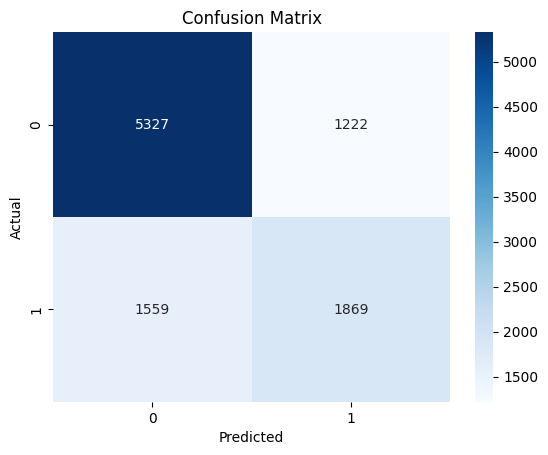

In [6]:
# Add confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, preds)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

<Axes: title={'center': 'Feature Importance'}>

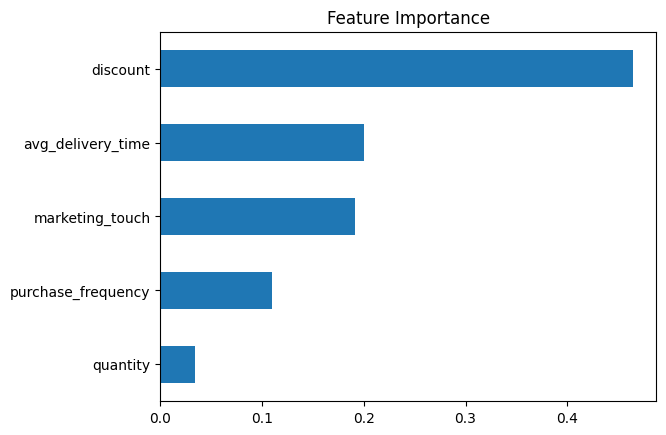

In [7]:
# Feature importance
import pandas as pd

importance = pd.Series(model.feature_importances_, index=features)
importance.sort_values().plot(kind='barh', title='Feature Importance')

📊 Business Insights from Customer Retention Model

● The model shows strong ability to identify non-repeat customers, making it useful for detecting potential churn early.
● However, a notable number of actual repeat customers are misclassified, indicating missed retention opportunities.
● Discounts are the most influential factor driving repeat purchases, highlighting strong customer price sensitivity.
● Faster delivery times significantly improve customer retention, emphasizing the importance of operational efficiency.
● Marketing engagement has a positive impact but is less effective without competitive pricing and good service experience.
● Purchase frequency contributes moderately to retention, while order quantity has minimal influence.

In [8]:
# Improve model
from xgboost import XGBClassifier

model = XGBClassifier()

In [9]:
# train the model
model = RandomForestClassifier(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

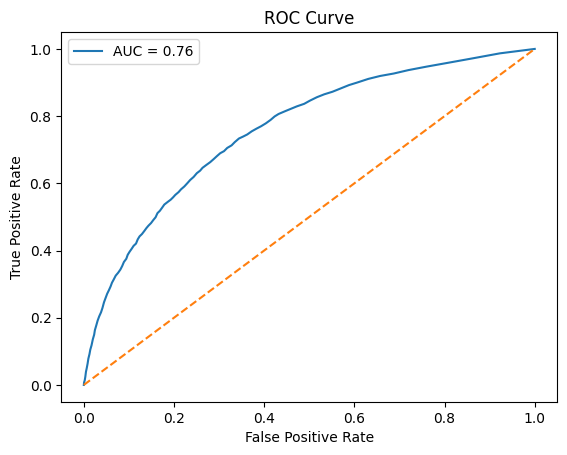

In [10]:
# ROC curve to make it more elite
from sklearn.metrics import roc_curve, auc

probs = model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, probs)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [11]:
# Tune model to improve performance
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

rf = RandomForestClassifier(random_state=42, class_weight='balanced')

search = RandomizedSearchCV(
    rf,
    param_distributions=param_grid,
    n_iter=10,
    cv=3,
    scoring='f1',
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

best_model = search.best_estimator_


In [12]:
# Re-evaluate with best model
preds = best_model.predict(X_test)
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

           0       0.85      0.73      0.79      6549
           1       0.60      0.76      0.67      3428

    accuracy                           0.74      9977
   macro avg       0.72      0.74      0.73      9977
weighted avg       0.76      0.74      0.75      9977



In [13]:
# Threshold tuning
probs = best_model.predict_proba(X_test)[:, 1]

custom_preds = (probs > 0.4).astype(int)  # try 0.3–0.5

print(classification_report(y_test, custom_preds))

              precision    recall  f1-score   support

           0       0.88      0.63      0.73      6549
           1       0.54      0.84      0.66      3428

    accuracy                           0.70      9977
   macro avg       0.71      0.73      0.69      9977
weighted avg       0.76      0.70      0.71      9977



In [14]:
# Customer segmentation
df_test = X_test.copy()
df_test['actual'] = y_test.values
df_test['probability'] = probs

df_test['segment'] = pd.cut(
    df_test['probability'],
    bins=[0, 0.3, 0.7, 1],
    labels=['Low Retention', 'Medium', 'High Retention']
)

df_test['segment'].value_counts()

segment
Low Retention     3953
Medium            3642
High Retention    2382
Name: count, dtype: int64

In [16]:
# Save model
import joblib
joblib.dump(best_model, 'model.pkl')

['model.pkl']

In [17]:
# create reusable pipeline
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('model', best_model)
])

joblib.dump(pipeline, 'pipeline.pkl')

['pipeline.pkl']

In [19]:
# Make it dashboard-ready
df_export = X_test.copy()
df_export['actual'] = y_test.values
df_export['predicted'] = preds
df_export['probability'] = probs

df_export.to_csv('customer_retention_prediction_dashboard_data.csv', index=False)